# Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline


## Research questions :
# What neighborhoods associated with the most and the least patients ?
# What's the relation between diseases and different ages, and their attendance?

In [2]:
df=pd.read_csv('noshowupp.csv')
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
df.isnull().sum().sum()

0

In [4]:
df.duplicated().sum().sum()

0

In [5]:
df.describe(include='all')

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
count,1.105270e+05,1.105270e+05,110527,110527,110527,110527.000000,110527,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527
unique,NaN,NaN,2,103549,27,NaN,81,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,F,2016-05-06T07:09:54Z,2016-06-06T00:00:00Z,NaN,JARDIM CAMBURI,NaN,NaN,NaN,NaN,NaN,NaN,No
freq,NaN,NaN,71840,24,4692,NaN,7717,NaN,NaN,NaN,NaN,NaN,NaN,88208
mean,1.474963e+14,5.675305e+06,NaN,NaN,NaN,37.088874,NaN,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026,NaN
std,2.560949e+14,7.129575e+04,NaN,NaN,NaN,23.110205,NaN,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873,NaN
min,3.921784e+04,5.030230e+06,NaN,NaN,NaN,-1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,4.172614e+12,5.640286e+06,NaN,NaN,NaN,18.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,3.173184e+13,5.680573e+06,NaN,NaN,NaN,37.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,9.439172e+13,5.725524e+06,NaN,NaN,NaN,55.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN


# - 78,140 patients are females (which is about 65%) while the rest 32,387 patients are males (about 35%) 

# - Average patient age is 37  

# - Highest number of patients is found in " Jardim Camburi" with 7717 patients


In [6]:
df['SMS_received'].value_counts()

0    75045
1    35482
Name: SMS_received, dtype: int64

# - About 75,045 patients received messages which is (67.9%) of total patients while the rest 35482 (32.1%) didn't

In [7]:
df.count()

PatientId         110527
AppointmentID     110527
Gender            110527
ScheduledDay      110527
AppointmentDay    110527
Age               110527
Neighbourhood     110527
Scholarship       110527
Hipertension      110527
Diabetes          110527
Alcoholism        110527
Handcap           110527
SMS_received      110527
No-show           110527
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


#  Data Cleaning :
# - no null/duplicated values found.
# - Illogical value noticed : minimum age is stated in negative numbers.
# - we will need to drop id columns since its useless in the data analysis process.

In [9]:
df.drop(['PatientId','AppointmentID'],axis=1,inplace=True)
df.head()

,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


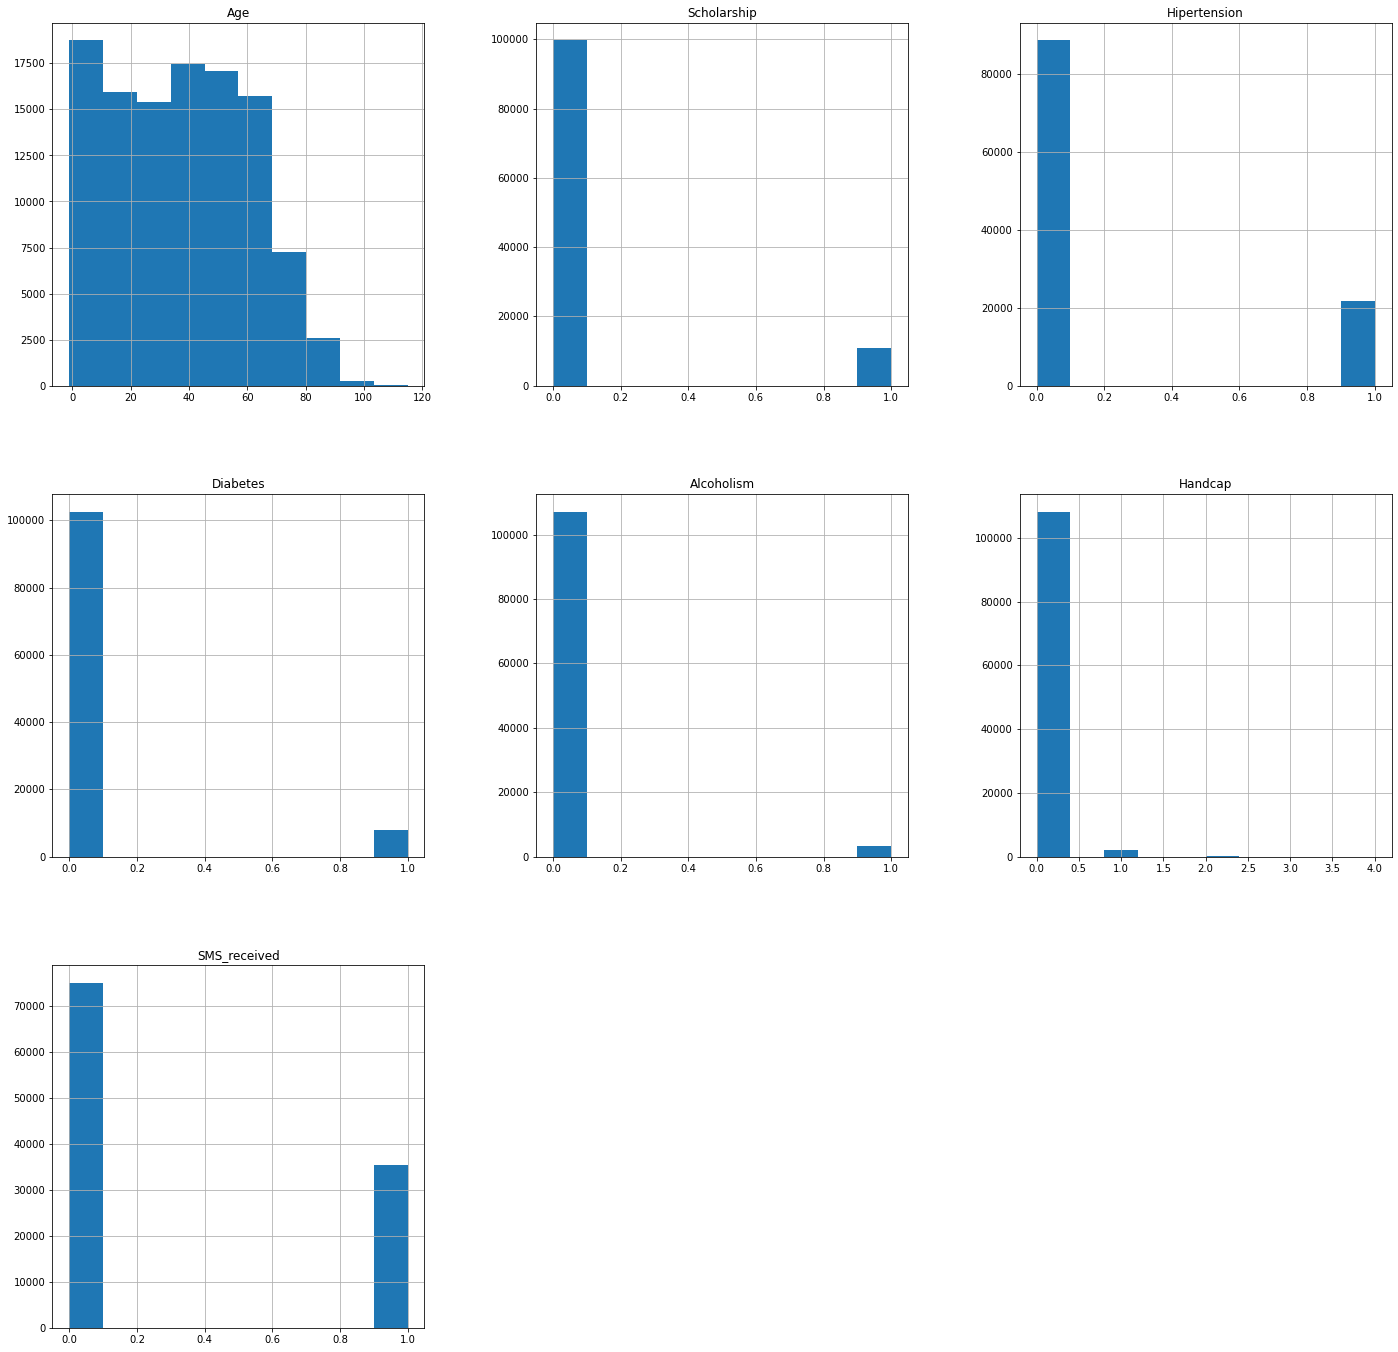

In [10]:
df.hist(figsize=(24,24));

# - Most patients aren't diabetic 
# - Most patients don't have hypertension
# - The majority of patients don't have a scholarship
# - About half of patients received an sms while the majority didn't
# - Most patients aren't handicapped
# - The majority of patients aren't alcoholic


# Question 1 : what neighborhoods associated with more patients?

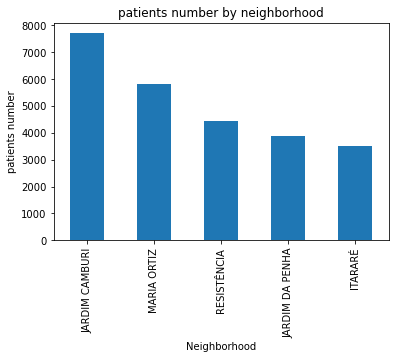

In [11]:
(df['Neighbourhood'].value_counts(normalize=False)).head().plot(kind='bar');
plt.title('patients number by neighborhood');
plt.xlabel('Neighborhood');
plt.ylabel('patients number');

# We notice that :
# - "Jardim Camburi" in the first place with the highest number of  patients 

# - Then "Maria Ortiz" in the second place 

# - Then "Resistencia" 

# - Then " Jardim da penha"

# - And lastly "Itarare"

In [12]:
df['Neighbourhood'].min()

'AEROPORTO'

# - Neighborhood with the lowest patients number is "Aeroporto"

In [13]:
showedup=df[df['No-show']=='No']
notshowedup=df[df['No-show']=='Yes']
print(showedup.count())
print(notshowedup.count())

Gender            88208
ScheduledDay      88208
AppointmentDay    88208
Age               88208
Neighbourhood     88208
Scholarship       88208
Hipertension      88208
Diabetes          88208
Alcoholism        88208
Handcap           88208
SMS_received      88208
No-show           88208
dtype: int64
Gender            22319
ScheduledDay      22319
AppointmentDay    22319
Age               22319
Neighbourhood     22319
Scholarship       22319
Hipertension      22319
Diabetes          22319
Alcoholism        22319
Handcap           22319
SMS_received      22319
No-show           22319
dtype: int64




## -88208 patients showed up (about 79.8% of total patients showed up)

## -22319 patients didnt show up (about 20.2% of total patients DID NOT show up)

# - Paitients who showed up and who didn't  according to age and disease :

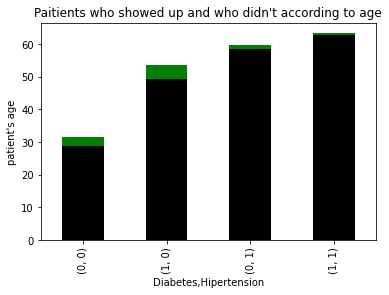

In [14]:
plt.title('Paitients who showed up and who didn\'t according to age');
showedup.groupby(['Diabetes','Hipertension']).mean()['Age'].sort_values().plot(kind='bar',color='green');
notshowedup.groupby(['Diabetes','Hipertension']).mean()['Age'].sort_values().plot(kind='bar',color='black');
plt.ylabel('patient\'s age');

 # - What days had the most patients ?

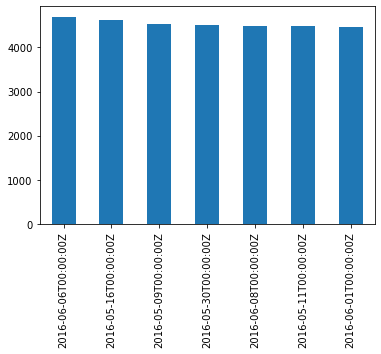

In [15]:
(df['AppointmentDay'].value_counts(normalize=False)).head(7).plot(kind='bar');